In [60]:
import torch
import pandas as pd
import numpy as np
import random
from torch import nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [61]:
class NeuralNetwork(nn.Module): #model architecture
    def __init__(self):
        super().__init__()
        #self.flatten = nn.Flatten()
        self.stack1 = nn.Sequential(nn.Linear(784,16),nn.ReLU(),nn.Linear(16,8),nn.ReLU())
        self.add_stack1 = nn.Sequential(nn.Linear(8,8),nn.ReLU())
        self.stack2 = nn.Sequential(nn.Linear(784,16),nn.ReLU(),nn.Linear(16,12),nn.ReLU(),nn.Linear(12,8),nn.ReLU())
        self.final = nn.Linear(16,10)
        
    def forward(self,x):
        #x = self.flatten(x)
        add1_ = self.stack1(x)
        add2_ = self.add_stack1(add1_)
        out1 = add1_ + add2_
        out2 = self.stack2(x)
        final_out = torch.concat([out1,out2],dim = 1)
        pred = self.final(final_out)
        return pred

In [62]:
def fw1(index): #loss calculation
        logits = NNN(torch.tensor(norm_features_file[index:index+1].to_numpy(), dtype=torch.float32))
        target = torch.tensor(target_file[index:index+1].to_numpy(), dtype=torch.long)
        loss = F.cross_entropy(logits,target[0])
        y_pred = F.softmax(logits,dim=1)
        #print(y_pred,target,loss)
        #print(F.cross_entropy(logits[0],target[0]),'loss with logits[0]','\n')
        return loss,y_pred

In [63]:
def gen(index): #trying to predict on unseen data
    logits = NNN(torch.tensor(norm_features_file[index:index+1].to_numpy(), dtype=torch.float32))
    target = torch.tensor(target_file[index:index+1].to_numpy(), dtype=torch.long)
    loss = F.cross_entropy(logits,target[0])
    y_pred = F.softmax(logits,dim=1)
    predicted_index =  torch.multinomial(y_pred[0], num_samples=1)
    #print(loss,predicted_index,target)
    return loss,predicted_index,target

In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("zalando-research/fashionmnist")

print("Path to dataset files:", path)

/Users/admin/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/admin/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /Users/admin/.cache/kagglehub/datasets/zalando-research/fashionmnist/versions/4


In [64]:
og_file = pd.read_csv('/Users/admin/.cache/kagglehub/datasets/zalando-research/fashionmnist/versions/4/fashion-mnist_train.csv')
features_file = og_file.iloc[:,1:]
target_file = og_file.iloc[:,[0]] # separating target file and features file

In [65]:
norm_features_file = pd.DataFrame()
for i in features_file.columns:
    norm_features_file[i]  = (features_file[i]  - features_file[i].mean())/features_file[i].std()
    
#normalising features file

/var/folders/cq/8d6xzvyx5ndc07c2_z7wjhnc0000gn/T/ipykernel_38556/1754817188.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  norm_features_file[i]  = (features_file[i]  - features_file[i].mean())/features_file[i].std()
/var/folders/cq/8d6xzvyx5ndc07c2_z7wjhnc0000gn/T/ipykernel_38556/1754817188.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  norm_features_file[i]  = (features_file[i]  - features_file[i].mean())/features_file[i].std()
/var/folders/cq/8d6xzvyx5ndc07c2_z7wjhnc0000gn/T/ipykernel_38556/1754817188.py:3: Performa

In [66]:
NNN = NeuralNetwork()
optimizer = torch.optim.AdamW(NNN.parameters(), lr=0.001)

In [67]:
c=0
error=[]
#loss calculation
for index in range(0,40000):
        
        #optimizer = torch.optim.AdamW(NNN.parameters(), lr=index*(10**(-3)))
        loss,ypred  =  fw1(index)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        error.append(loss.item())
        c+=1
        if c%1000==0:
            print(loss.item())
    

0.00805013906210661
0.38710853457450867
0.012223217636346817
0.14199061691761017
2.6777148246765137
0.006093021482229233
3.0598948001861572
0.00237266649492085
0.027248075231909752
0.010366876609623432
0.24753819406032562
1.4287395477294922
6.556489552167477e-06
0.004450891632586718
0.0006658005877397954
0.029281893745064735
0.04086899012327194
0.0035115741193294525
1.2412693500518799
6.16293036728166e-05
0.022553840652108192
2.3841855067985307e-07
0.006684324704110622
0.1595209538936615
0.0008659188752062619
0.003915620967745781
0.0010637345258146524
1.003093957901001
0.02106204442679882
0.0051497905515134335
0.11271137744188309
0.0936049222946167
0.4556441307067871
0.08396203070878983
0.012658249586820602
0.09870179742574692
0.0004389514506328851
0.18214982748031616
0.00026770823751576245
0.8556117415428162


In [71]:
c_t = 0
val_error= []
#trying to predict from unseen data
optimizer.zero_grad(set_to_none=True)
for index in range(40000,50000):
    loss,ypred,target  =  gen(index)
    print(loss.item())
    val_error.append(loss.item())
    if ypred.item()==target.item():
        c_t+=1
print(c_t)

0.010537461377680302
0.00040737437666393816
0.19096584618091583
0.9004888534545898
0.03040977567434311
1.5616295058862306e-05
0.14958210289478302
5.8412379075889476e-06
0.10331516712903976
0.006770882289856672
1.1296507120132446
0.05391872674226761
0.03999432176351547
6.437280717364047e-06
0.7240208983421326
0.06593268364667892
0.003937825560569763
0.0434550903737545
1.0735775232315063
0.00608555693179369
0.0012004319578409195
0.0010839784517884254
0.059638820588588715
0.0819973349571228
0.13669000566005707
0.057013895362615585
0.0005007919971831143
0.020624464377760887
0.0646897703409195
0.46482229232788086
0.6174387335777283
5.686121585313231e-05
0.30071645975112915
0.03736536577343941
0.00023850933939684182
1.0607783794403076
0.24411289393901825
7.152555099310121e-07
5.006777428206988e-06
0.00823755282908678
0.005621102638542652
0.14514026045799255
0.08706331253051758
0.9687805771827698
0.29071661829948425
0.41700637340545654
1.2516897186287679e-05
0.4256141483783722
0.0008233971311

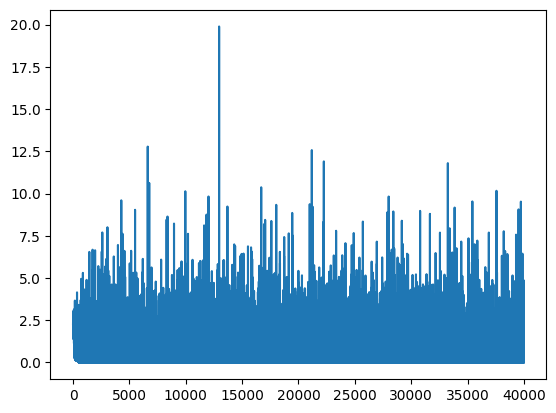

In [72]:
plt.plot(error) # loss vs epoch plot
plt.show()

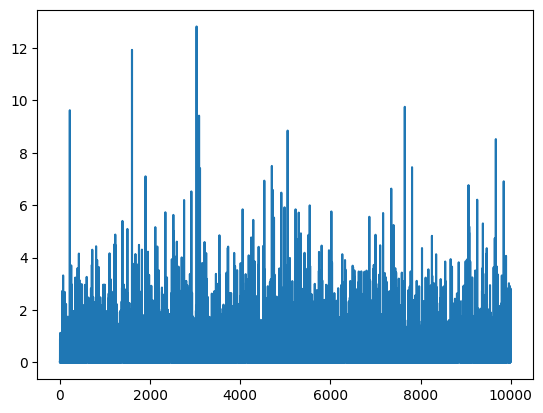

In [73]:
plt.plot(val_error) # loss vs epoch plot - validation
plt.show()

In [59]:
import pickle

In [75]:
with open('model_weights.pkl','wb') as file:
    pickle.dump(NNN, file)

In [112]:
c_t = 0
test_error= []
prediction=[]
actual_label = []
#trying to predict from unseen data
#creation of prediction including csv file
optimizer.zero_grad(set_to_none=True)
for index in range(50000,60000):
    loss,ypred,target  =  gen(index)
    prediction.append(ypred)
    actual_label.append(target)
    test_error.append(loss.item())
    f1.writerow([ypred.item(),target.item(),loss.item()])
    if ypred.item()==target.item():
        c_t+=1
print(c_t)

7695


In [111]:
#with open('submission.csv','w') as file:
file1 = open('submission.csv','w')
f1 = csv.writer(file1)
f1.writerow(['Predicted target','Actual Index','loss'])

36

In [85]:
import csv

In [113]:
file1.close()